# **Ievads attēlu apstrādē**
## **Praktiskais darbs Nr. 1**
---

**Students:** Rihards Irbe

**Studenta apliecības Nr.:** 251RDB259

**Saite uz programmēšanas kodu:** https://colab.research.google.com/drive/1lmArmWL1zDE_Dr0vfN4QRAJIoPh3nYUk#scrollTo=Gz_9b9xw5L_C&line=4&uniqifier=1

## **Programmas kods ar izvadi**

/tmp/ipykernel_15562/3630711190.py:35: RuntimeWarning: divide by zero encountered in divide
  C = np.where(denom <= eps, 1.0, B / denom)
/tmp/ipykernel_15562/3630711190.py:35: RuntimeWarning: invalid value encountered in divide
  C = np.where(denom <= eps, 1.0, B / denom)


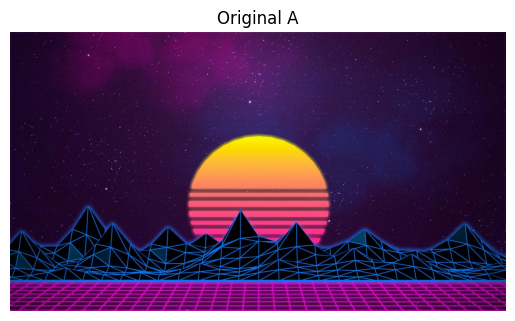

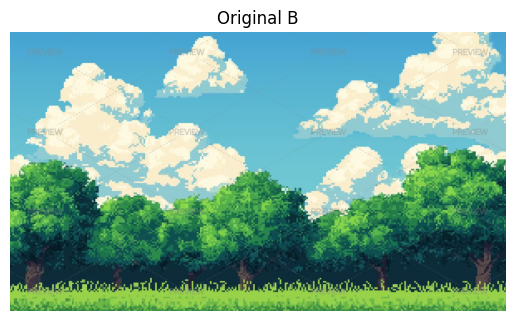

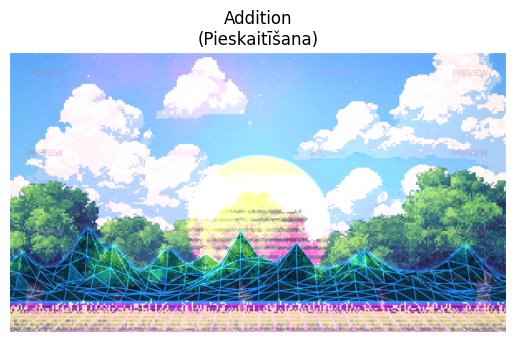

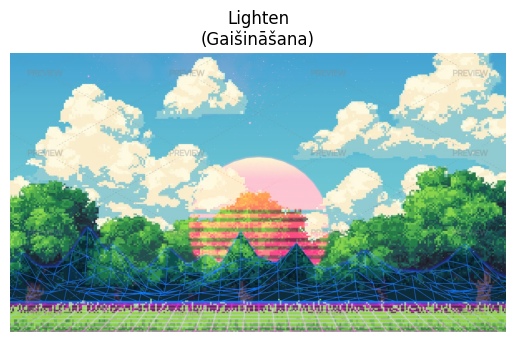

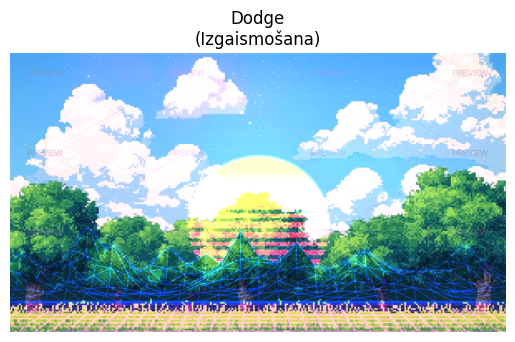

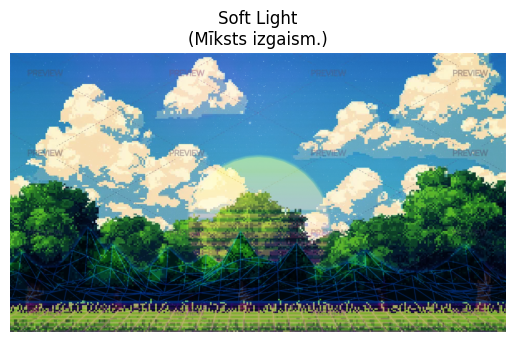

In [1]:
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

def download_image(url):
    response = requests.get(url)

    if(response.status_code == 200):
        return Image.open(BytesIO(response.content)).convert("RGB")

    print("Something went wrong");
    return 0;

def pil_to_value_arr(img):
    return np.asarray(img, dtype=np.float32) / 255.0

def value_arr_to_pil(arr):
    return Image.fromarray((np.clip(arr, 0.0, 1.0) * 255).astype(np.uint8))

def ensure_same_size(img_a, img_b):
    if img_a.size != img_b.size:
        img_b = img_b.resize(img_a.size, Image.LANCZOS)
    return img_a, img_b

def blend_addition(A, B):
    return np.clip(A + B, 0.0, 1.0)

def blend_lighten(A, B):
    return np.maximum(A, B)

def blend_dodge(A, B, eps=1e-12):
    denom = 1.0 - A
    C = np.where(denom <= eps, 1.0, B / denom)
    return np.clip(C, 0.0, 1.0)

def blend_soft_light(A, B):
    C = np.empty_like(A)
    mask = A <= 0.5

    a1, b1 = A[mask], B[mask]
    C[mask] = (2 * a1 - 1) * (b1 - b1**2) + b1

    a2, b2 = A[~mask], B[~mask]
    C[~mask] = (2 * a2 - 1) * (np.sqrt(np.clip(b2, 0.0, 1.0)) - b2) + b2

    return np.clip(C, 0.0, 1.0)

URL_A = "https://images7.alphacoders.com/737/737638.jpg"
URL_B = "https://cms-artifacts.motionarray.com/content/motion-array/3293114/Pixel_Art_Forest_Trees_And_Sky_Landscape_high_resolution_preview_3293114.jpg?Expires=2056561714&Key-Pair-Id=K2ZDLYDZI2R1DF&Signature=U3gY972LKx7wMSLt6nY-vzc-zZspAn-GsGrUbLoWOp3tRUpPKtB0pPwyE1AZu6h3tt12XzWXRO5CPUtrzyHbYrmYaBtN-PNQiRjFm4xigudw7NYjrro3Vi6HO65q3sAopfNyYeVTXMuIF7JcPWCRQ25wf1rA7mlZdDLIN3sV3b5Up9xElSO56MwYXSDQ6H9INZbvjiiY7T36XD6B4t17V28YJj7fIAuw2TgSzt4cIsxn622vA1rRi0bDVeEF8HVA7mKQBEvw2fqeRxavPC8Gx7x7ygBgzzsm6BdgDXUvIu7faZrgyjiwUG1xPmV91IbtvE0ovcXe6u3XB20qojF02g__"

img_a, img_b = ensure_same_size(download_image(URL_A), download_image(URL_B))
A = pil_to_value_arr(img_a)
B = pil_to_value_arr(img_b)

results = {
    "Original A":                    A,
    "Original B":                    B,
    "Addition\n(Pieskaitīšana)":     blend_addition(A, B),
    "Lighten\n(Gaišināšana)":        blend_lighten(A, B),
    "Dodge\n(Izgaismošana)":         blend_dodge(A, B),
    "Soft Light\n(Mīksts izgaism.)": blend_soft_light(A, B),
}

for title, img in results.items():
    plt.figure()
    plt.title(title)
    plt.imshow(np.clip(img, 0, 1))
    plt.axis("off")
    plt.show()


# **Secinājumi**

Izaicinājumi:

Tā kā šī bija pirmā reize kad veicu attēlu apstrādi ar programmēšanu man bija problēmas saprast koda loģiku, taču ar MI izpildīju pareizi uzdevumu, proti, visi attēli izskatījās pareizi pārveidoti, tad sāku izprast pašu koda loģiku.

Grūtākāis efekts, ko realizēju bija Mīkstais izgaismojums, jo šī formula bija viskompleksākā.

Tika pielietotas bibliotēkas, kuras līdz šim nebiju izmantojis vai neizmantoju regulāri, kā PIL un io.

Ieguvumi:

Praktiska pieredze attēlu apstrādē ar python. Uzlaboju savas python zināšanas ar jaunām sintaksēm un operatoriem, kā piemēram, "~" operātoru.

Sapratu arī pamatus attēlu apstrādei, kā šie attēli tiek pārveidoti, kā tiek saglabāti un kādas darbības ar tiem var veikt. Līdz šim domāju ka attēli sastāv no 2d masīva, kurš ir attēla rezolūcijas izmērā un katrs index sastāv no RGB skaitlisko vērtību, bet izrādās ka attēli tiek saglabāti kā 3d masīvi.